This notebook uses PCA to explore patterns in U.S. immigration between 1980-2022. PCA allows us to identify the immigration features that move together and the ones who operate separately.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
immigration = pd.read_csv('US Immigration Statistics (Ver 1.14.26).csv')
immigration = immigration[~immigration['Year'].isin([1991, 2003, 2020, 2021, 2022])]

immigration = immigration.rename(columns={
    "Immigrants Obtaining Lawful Permanent Resident Status": "Obtaintment of Permanent Residence"
})

print(immigration.head())

     Year Obtaintment of Permanent Residence Refugee Arrivals  \
0  1980.0                            524,295          207,116   
1  1981.0                            595,014          159,252   
2  1982.0                            533,624           98,096   
3  1983.0                            550,052           61,218   
4  1984.0                            541,811           70,393   

  Noncitizen Apprehensions Noncitizen Removals Noncitizen Returns  
0                  910,361              18,013            719,211  
1                  975,780              17,379            823,875  
2                  970,246              15,216            812,572  
3                1,251,357              19,211            931,600  
4                1,246,981              18,696            909,833  


In [5]:
immigration.columns

Index(['Year', 'Obtaintment of Permanent Residence', 'Refugee Arrivals',
       'Noncitizen Apprehensions', 'Noncitizen Removals',
       'Noncitizen Returns'],
      dtype='object')

In [6]:
#convert features to float type
immigration = immigration.dropna()

features = [
    "Obtaintment of Permanent Residence",
    "Refugee Arrivals",
    "Noncitizen Apprehensions",
    "Noncitizen Removals",
    "Noncitizen Returns"
]

for f in features:
    immigration[f] = (
        immigration[f].str.replace(",", "").astype(float)
    )

In [7]:
immigration.dtypes

Year                                  float64
Obtaintment of Permanent Residence    float64
Refugee Arrivals                      float64
Noncitizen Apprehensions              float64
Noncitizen Removals                   float64
Noncitizen Returns                    float64
dtype: object

In [8]:
#scale number of feature to be similar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(immigration.drop(columns=['Year']))

In [9]:
#view outliers
z_scores = np.abs(X_scaled)
outlier_years = immigration['Year'][np.any(z_scores > 2, axis=1)]
print(outlier_years.values)

[1980. 1981. 1990. 2000.]


In [10]:
#run PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

In [11]:
#df for PCA results
immigration_pca = pd.DataFrame(
    components,
    columns=['PC1', 'PC2']
)
immigration_pca['Year'] = immigration['Year'].values
print(immigration_pca.head())

        PC1       PC2    Year
0  1.697148  3.806488  1980.0
1  1.432154  2.571585  1981.0
2  1.067945  1.390802  1982.0
3  1.294599  0.102897  1983.0
4  1.348690  0.324697  1984.0


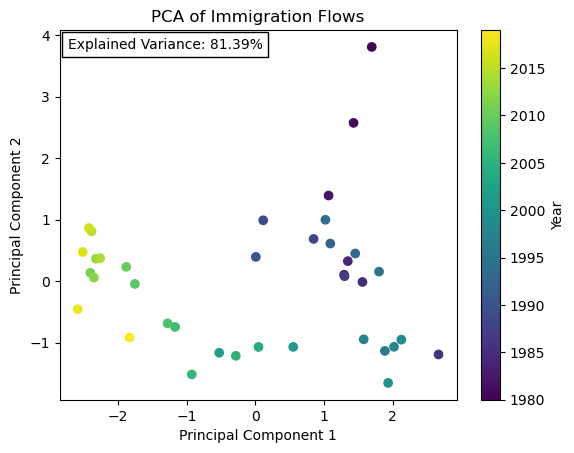

In [42]:
#plot PCA
explained = pca.explained_variance_ratio_.sum() * 100

plt.scatter(
    immigration_pca["PC1"],
    immigration_pca["PC2"],
    c=immigration_pca["Year"]
)

plt.title("PCA of Immigration Flows")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.text(
    0.02, 0.98,
    f"Explained Variance: {explained:.2f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.colorbar(label="Year")

plt.show()

In [13]:
#df for PCA loadings 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=immigration.drop(columns=["Year"]).columns
)

print(loadings)

                                         PC1       PC2
Obtaintment of Permanent Residence -0.415543 -0.246663
Refugee Arrivals                    0.257686  0.714104
Noncitizen Apprehensions            0.482387 -0.479873
Noncitizen Removals                -0.510126 -0.259940
Noncitizen Returns                  0.517683 -0.362444


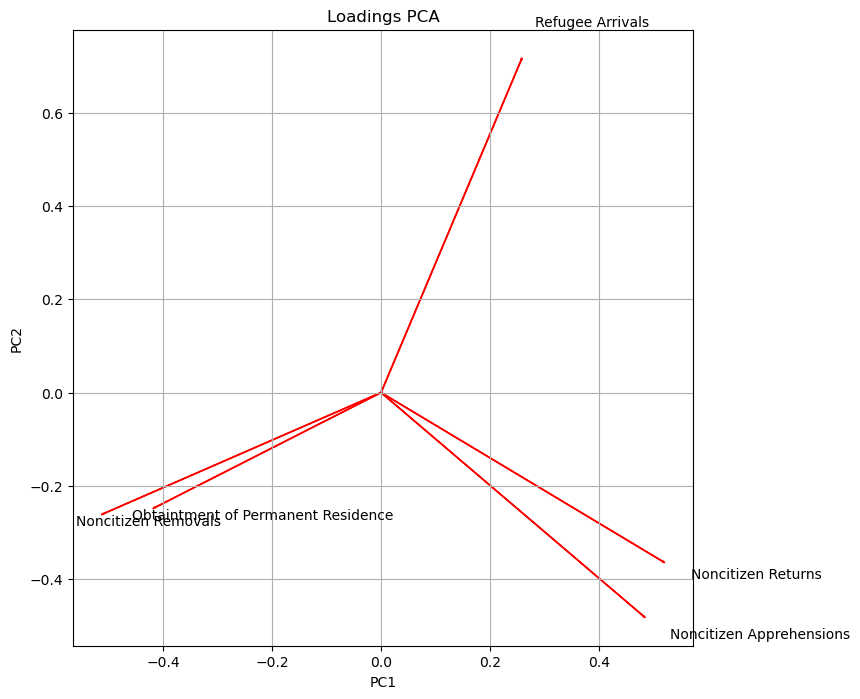

In [41]:
#plotted PCA loadings
plt.figure(figsize=(8, 8))

for feature in loadings.index:
    x = loadings.loc[feature, "PC1"]
    y = loadings.loc[feature, "PC2"]
    plt.arrow(0, 0, x, y, color="red")
    plt.text(x * 1.1, y * 1.1, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings PCA")
plt.grid(True)
plt.show()

The graph above indicates no relationship between refugee arrivals and noncitizen returns and noncitizen apprehensions. 

There also seems to be a positive correlation between noncitizen removals and obtainments of permanent residence statuses.

In [15]:
#calculate pc1 scores for each feature to see how much each one contributed
pc1_loadings = pd.Series(
    pca.components_[0],
    index=immigration.drop(columns=['Year']).columns
)

contributions = pd.DataFrame(
    X_scaled * pc1_loadings.values,
    columns=immigration.drop(columns=['Year']).columns
)
contributions['Year'] = immigration['Year'].values

print(contributions.head())

   Obtaintment of Permanent Residence  Refugee Arrivals  \
0                            0.650737          0.969106   
1                            0.530128          0.612278   
2                            0.634826          0.156358   
3                            0.606809         -0.118569   
4                            0.620864         -0.050169   

   Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns    Year  
0                 -0.326957             0.572374           -0.168112  1980.0  
1                 -0.230662             0.574563           -0.054153  1981.0  
2                 -0.238808             0.582028           -0.066459  1982.0  
3                  0.174979             0.568240            0.063139  1983.0  
4                  0.168538             0.570017            0.039439  1984.0  


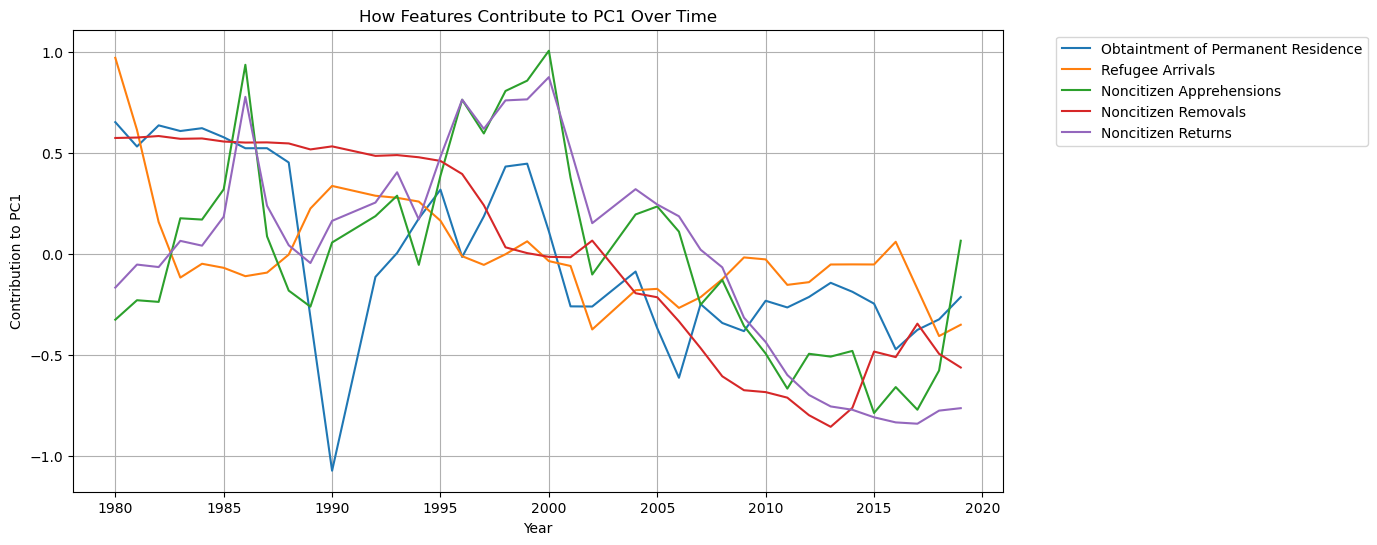

In [16]:
#plot pc1 contributions
fig, ax = plt.subplots(figsize=(12, 6))

for feature in contributions.drop(columns=['Year']).columns:
    ax.plot(contributions['Year'], contributions[feature], label=feature)

ax.set_title("How Features Contribute to PC1 Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Contribution to PC1")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.show()

The plot above shows that refugee arrivals had the highest PC1 contributions around 1980 but then it drops below 0 around 1990 and after 2000. Noncitizen removals and returns seem to rise and fall and are a little unpredictable. After the 2000s noncitizen removals and returns both decline in a similar fashion suggesting they contributed to the immigration patterns in later years.

In [17]:
#calculate pc2 scores for each feature to see how much each one contributed
pc2_loadings = pd.Series(
    pca.components_[1],
    index=immigration.drop(columns=['Year']).columns
)

contributions2 = pd.DataFrame(
    X_scaled * pc2_loadings.values,
    columns=immigration.drop(columns=['Year']).columns
)
contributions2['Year'] = immigration['Year'].values

print(contributions2.head())

   Obtaintment of Permanent Residence  Refugee Arrivals  \
0                            0.386272          2.685604   
1                            0.314680          1.696757   
2                            0.376828          0.433303   
3                            0.360197         -0.328579   
4                            0.368540         -0.139028   

   Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns    Year  
0                  0.325253             0.291659            0.117699  1980.0  
1                  0.229460             0.292774            0.037914  1981.0  
2                  0.237564             0.296578            0.046530  1982.0  
3                 -0.174067             0.289552           -0.044205  1983.0  
4                 -0.167660             0.290458           -0.027612  1984.0  


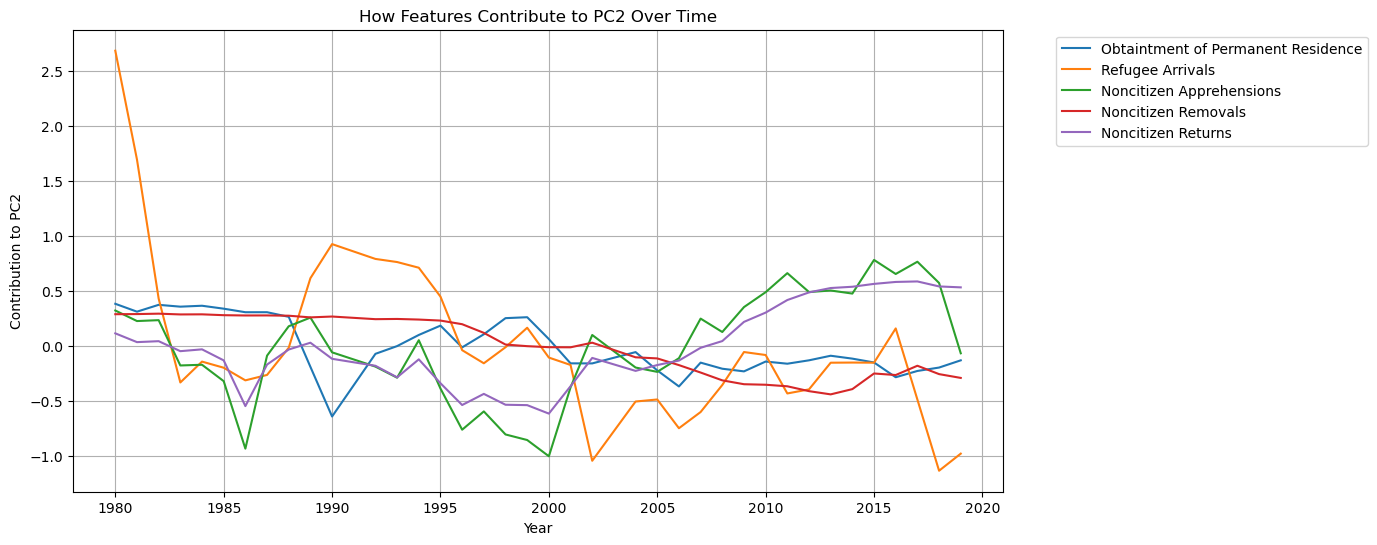

In [18]:
#plot pc2 contributions
fig, ax = plt.subplots(figsize=(12, 6))

for feature in contributions2.drop(columns=['Year']).columns:
    ax.plot(contributions2['Year'], contributions2[feature], label=feature)

ax.set_title("How Features Contribute to PC2 Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Contribution to PC2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.show()

PC2 normally captures the patterns of features that dont fit in with those in PC1- In this plot, we see that refugee arrivals is behaving quite differently to all the other features. While there are slight variances between obtainment of permanent residency, noncitizen apprehensions, noncitizen removals, and noncitizen returns they all follow similar trends. This could indicate that refugee arrivals are driven by outside factors such as global conflicts. Overall, this explains why refugee arrivals moved in opposing directions to that of the other features.

-----------------------------------------------------------------------------------------------------------
Now we are cursious on what results we will get when running PCA on the immigration features over the years:

2008-2016 

2017-2022

In [24]:
#reloads dataset without year exclusions
immigration_complete = pd.read_csv('US Immigration Statistics (Ver 1.14.26).csv')
immigration_complete = immigration_complete.rename(columns={
    "Immigrants Obtaining Lawful Permanent Resident Status": "Obtaintment of Permanent Residence"
})

for f in features:
    immigration_complete[f] = immigration_complete[f].str.replace(",", "").astype(float)

immigration_complete = immigration_complete.dropna()
print(immigration_complete['Year'].unique())

[1980. 1981. 1982. 1983. 1984. 1985. 1986. 1987. 1988. 1989. 1990. 1991.
 1992. 1993. 1994. 1995. 1996. 1997. 1998. 1999. 2000. 2001. 2002. 2003.
 2004. 2005. 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015.
 2016. 2017. 2018. 2019. 2020. 2021. 2022.]


In [31]:
immigration_2008_2016 = immigration_complete[immigration_complete['Year'].between(2008, 2016)]
immigration_2017_2022 = immigration_complete[immigration_complete['Year'].between(2017, 2022)]

print("Immigration 2008-2016 \n", immigration_2008_2016.head(), "\n---------------------------------------------------------------------------------\n")
print("Immigration 2017-2022 \n", immigration_2017_2022.head())

Immigration 2008-2016 
       Year  Obtaintment of Permanent Residence  Refugee Arrivals  \
28  2008.0                           1107126.0           60107.0   
29  2009.0                           1130818.0           74602.0   
30  2010.0                           1042625.0           73293.0   
31  2011.0                           1062040.0           56384.0   
32  2012.0                           1031631.0           58179.0   

    Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns  
28                 1043759.0             359795.0            811263.0  
29                  889212.0             379739.0            582567.0  
30                  796587.0             382449.0            471798.0  
31                  678606.0             390413.0            322046.0  
32                  795735.0             415579.0            231105.0   
---------------------------------------------------------------------------------

Immigration 2017-2022 
       Year  Obtaintment of 

In [36]:
#scale and run PCA for 2008-2016
scaler1 = StandardScaler()
X1 = scaler1.fit_transform(immigration_2008_2016[features])

pca1 = PCA(n_components=2)
components1 = pca1.fit_transform(X1)

In [37]:
#df for 2008-2016 PCA results
df_2008_2016 = pd.DataFrame(
    components1,
    columns=['PC1', 'PC2']
)
df_2008_2016['Year'] = immigration_2008_2016['Year'].values

print(df_2008_2016.head())

        PC1       PC2    Year
0 -1.524980  2.794572  2008.0
1  0.096077  1.717065  2009.0
2 -0.165844  0.203915  2010.0
3 -0.555049 -0.739730  2011.0
4 -1.319460 -0.988069  2012.0


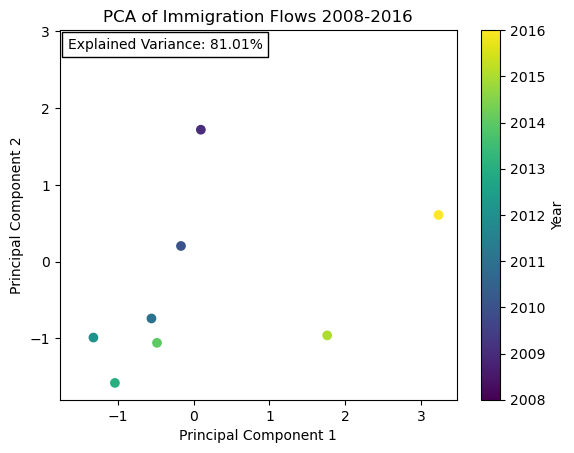

In [39]:
#plot PCA 2008-2016
explained1 = pca1.explained_variance_ratio_.sum() * 100

plt.scatter(
    df_2008_2016["PC1"],
    df_2008_2016["PC2"],
    c=df_2008_2016["Year"]
)

plt.title("PCA of Immigration Flows 2008-2016")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.text(
    0.02, 0.98,
    f"Explained Variance: {explained1:.2f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.colorbar(label="Year")
plt.show()

In [46]:
#df for 2008-2016 PCA loadings
loadings1 = pd.DataFrame(
    pca1.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print(loadings1)

                                         PC1       PC2
Obtaintment of Permanent Residence  0.406807  0.520566
Refugee Arrivals                    0.524331  0.081459
Noncitizen Apprehensions           -0.428410  0.505542
Noncitizen Removals                -0.518028 -0.311923
Noncitizen Returns                 -0.328172  0.607871


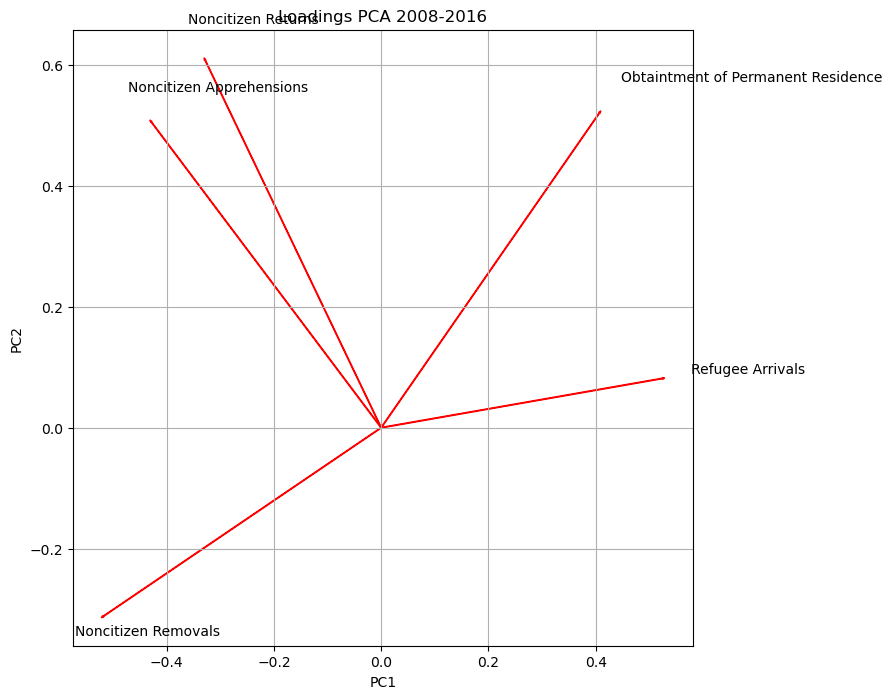

In [47]:
#plot 2008-2016 loadings
plt.figure(figsize=(8, 8))

for feature in loadings1.index:
    x = loadings1.loc[feature, "PC1"]
    y = loadings1.loc[feature, "PC2"]
    plt.arrow(0, 0, x, y, color="red")
    plt.text(x * 1.1, y * 1.1, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings PCA 2008-2016")
plt.grid(True)
plt.show()

In [54]:
#calculate pc1 contributions for 2008-2016
pc1_loadings1 = pd.Series(
    pca1.components_[0],
    index=features
)

contributions1 = pd.DataFrame(
    X1 * pc1_loadings1.values,
    columns=features
)
contributions1['Year'] = immigration_2008_2016['Year'].values

print(contributions1.head())

   Obtaintment of Permanent Residence  Refugee Arrivals  \
0                            0.273793         -0.518962   
1                            0.441415          0.367237   
2                           -0.182553          0.287207   
3                           -0.045191         -0.746580   
4                           -0.260336         -0.636837   

   Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns    Year  
0                 -0.899127             0.309113           -0.689797  2008.0  
1                 -0.359611             0.006931           -0.359895  2009.0  
2                 -0.036261            -0.034130           -0.200108  2010.0  
3                  0.375605            -0.154796            0.015914  2011.0  
4                 -0.033287            -0.536100            0.147099  2012.0  


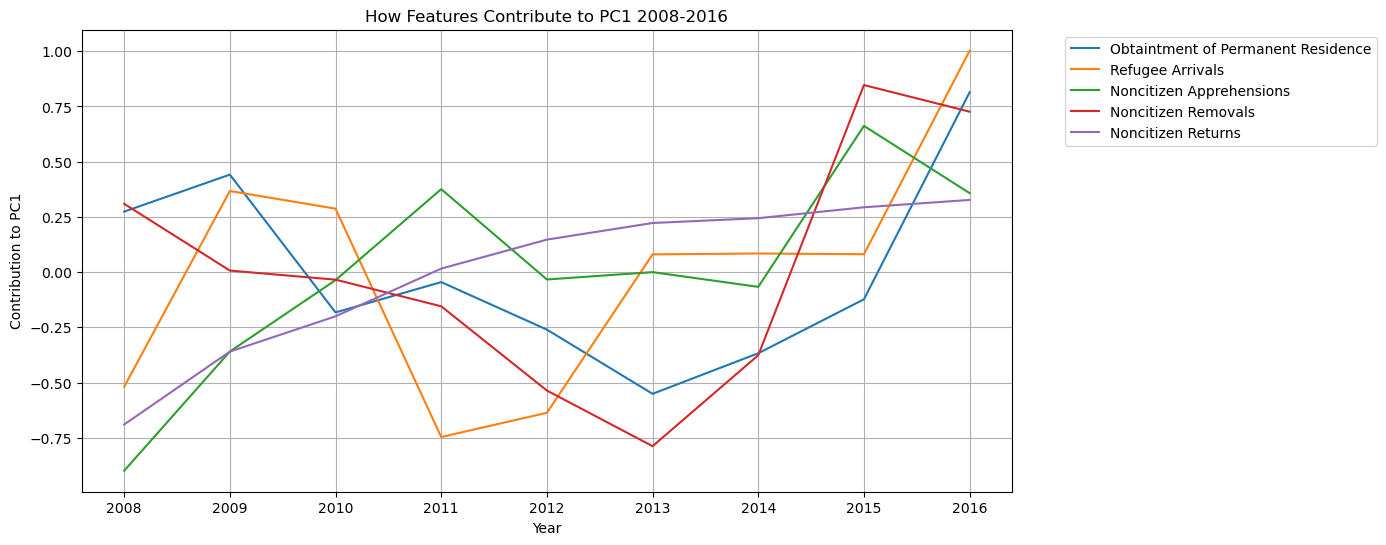

In [55]:
#plot pc1 contributions 2008-2016
fig, ax = plt.subplots(figsize=(12, 6))

for feature in contributions1.drop(columns=['Year']).columns:
    ax.plot(contributions1['Year'], contributions1[feature], label=feature)

ax.set_title("How Features Contribute to PC1 2008-2016")
ax.set_xlabel("Year")
ax.set_ylabel("Contribution to PC1")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.show()

The PC1 contributions above show that all the immigration features are all over the place meaning there is no features that dominates in the contribution to PC1. During different instances certain features dominate the others (2011 is noncitizen apprehensions, 2015 is noncitizen removals). An interesting observation is that after 2015 there seems to be a big spike among refugee arrivals and obtainment of permanent residence status.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [48]:
#scale and run PCA for 2017-2022
scaler2 = StandardScaler()
X2 = scaler2.fit_transform(immigration_2017_2022[features])

pca2 = PCA(n_components=2)
components2 = pca2.fit_transform(X2)

In [49]:
#df for 2017-2022 PCA results
df_2017_2022 = pd.DataFrame(
    components2,
    columns=['PC1', 'PC2']
)
df_2017_2022['Year'] = immigration_2017_2022['Year'].values

print(df_2017_2022.head())

        PC1       PC2    Year
0  2.609936  0.628884  2017.0
1  1.143012 -0.099158  2018.0
2  0.933768  0.255219  2019.0
3 -0.443114 -1.898443  2020.0
4 -2.027160 -0.737234  2021.0


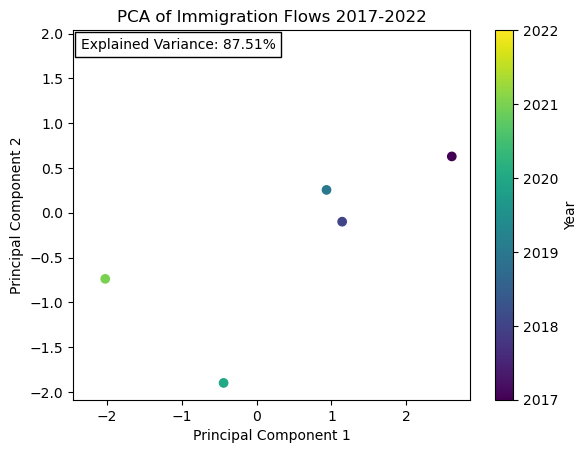

In [50]:
#plot PCA 2017-2022
explained2 = pca2.explained_variance_ratio_.sum() * 100

plt.scatter(
    df_2017_2022["PC1"],
    df_2017_2022["PC2"],
    c=df_2017_2022["Year"]
)

plt.title("PCA of Immigration Flows 2017-2022")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.text(
    0.02, 0.98,
    f"Explained Variance: {explained2:.2f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.colorbar(label="Year")
plt.show()

In [51]:
#df for 2017-2022 PCA loadings
loadings2 = pd.DataFrame(
    pca2.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print(loadings2)

                                         PC1       PC2
Obtaintment of Permanent Residence  0.358023  0.640401
Refugee Arrivals                    0.420659  0.486363
Noncitizen Apprehensions           -0.466595  0.483318
Noncitizen Removals                 0.498497 -0.100283
Noncitizen Returns                 -0.478178  0.331188


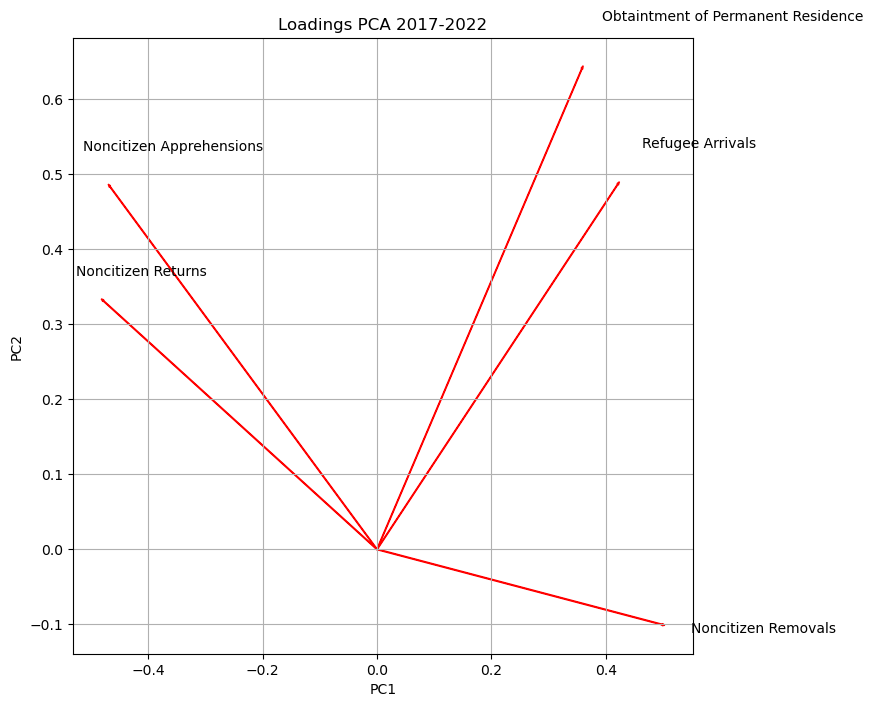

In [52]:
#plot 2017-2022 loadings
plt.figure(figsize=(8, 8))

for feature in loadings2.index:
    x = loadings2.loc[feature, "PC1"]
    y = loadings2.loc[feature, "PC2"]
    plt.arrow(0, 0, x, y, color="red")
    plt.text(x * 1.1, y * 1.1, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings PCA 2017-2022")
plt.grid(True)
plt.show()

In [56]:
#calculate pc1 contributions for 2017-2022
pc1_loadings2 = pd.Series(
    pca2.components_[0],
    index=features
)

contributions2 = pd.DataFrame(
    X2 * pc1_loadings2.values,
    columns=features
)
contributions2['Year'] = immigration_2017_2022['Year'].values

print(contributions2.head())

   Obtaintment of Permanent Residence  Refugee Arrivals  \
0                            0.372444          0.827034   
1                            0.306897         -0.100814   
2                            0.167795          0.121940   
3                           -0.528086         -0.414140   
4                           -0.458069         -0.425587   

   Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns    Year  
0                  0.416064             0.256751            0.737644  2017.0  
1                  0.332461             0.471037            0.133431  2018.0  
2                  0.055692             0.568277            0.020064  2019.0  
3                  0.415057             0.026706            0.057349  2020.0  
4                 -0.381665            -0.709790           -0.052048  2021.0  


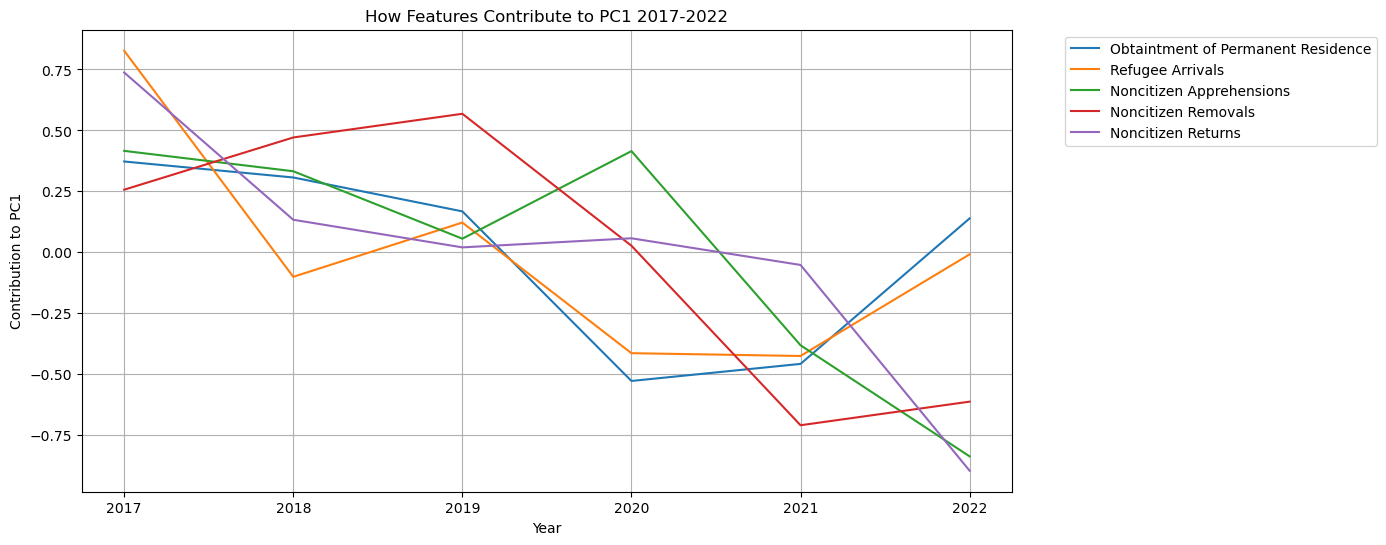

In [57]:
#plot pc1 contributions 2017-2022
fig, ax = plt.subplots(figsize=(12, 6))

for feature in contributions2.drop(columns=['Year']).columns:
    ax.plot(contributions2['Year'], contributions2[feature], label=feature)

ax.set_title("How Features Contribute to PC1 2017-2022")
ax.set_xlabel("Year")
ax.set_ylabel("Contribution to PC1")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.show()

For these PC1 contributions, all features seem to start positively and decrease in similar patterns. There is a big drop in 2020 with refugee arrivals and obtainment of permanent residence status which would make sense since this was during COVID. Removals are generally high until about 2019, then it drops significantly until 2021. Noncitizen apprehensions and noncitizen returns both drop (noncitizen apprehensions is quite a significant drop after 2021, where noncitizen returns drops significantly after 2022).